# Task 1

### Spark Session Setup

In [1]:
from pyspark.sql import SparkSession

# Create or get the Spark session
spark = SparkSession.builder \
    .appName("Airline Delay Prediction - Project 4") \
    .config("spark.executor.memory", "2g") \
    .config("spark.driver.memory", "1g") \
    .getOrCreate()

print(f"Spark version: {spark.version}")


Spark version: 3.5.3


### Load 2009 CSV Data (Need to add 2010 when it is available)

In [2]:
# Load 2009 data as DataFrame
csv_path = "/home/jovyan/lab_data/2009.csv"

df_2009 = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("ignoreLeadingWhiteSpace", "true") \
    .option("ignoreTrailingWhiteSpace", "true") \
    .load(csv_path)

# Show a sample
df_2009.show(5)


+----------+----------+-----------------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+---------+-----------------+--------+----------------+-------------------+--------+--------+-------------+-------------+---------+--------------+-------------------+-----------+
|   FL_DATE|OP_CARRIER|OP_CARRIER_FL_NUM|ORIGIN|DEST|CRS_DEP_TIME|DEP_TIME|DEP_DELAY|TAXI_OUT|WHEELS_OFF|WHEELS_ON|TAXI_IN|CRS_ARR_TIME|ARR_TIME|ARR_DELAY|CANCELLED|CANCELLATION_CODE|DIVERTED|CRS_ELAPSED_TIME|ACTUAL_ELAPSED_TIME|AIR_TIME|DISTANCE|CARRIER_DELAY|WEATHER_DELAY|NAS_DELAY|SECURITY_DELAY|LATE_AIRCRAFT_DELAY|Unnamed: 27|
+----------+----------+-----------------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+---------+-----------------+--------+----------------+-------------------+--------+--------+-------------+-------------+---------+--------------+-------------------+-----------+
|

### Write as Partitioned Parquet

In [3]:
output_path = "/home/jovyan/lab_data/2009_parquet_partitioned"

df_2009.write \
    .mode("overwrite") \
    .partitionBy("OP_CARRIER") \
    .parquet(output_path)

print("Parquet written with partitioning.")


Parquet written with partitioning.


# Task 2

### Rename Columns

In [4]:
from pyspark.sql.functions import col

df_cleaned = df_2009 \
    .withColumnRenamed("OP_CARRIER", "uniqueCarrier") \
    .withColumnRenamed("FL_DATE", "flightDate") \
    .withColumnRenamed("OP_CARRIER_FL_NUM", "flightNumber") \
    .withColumnRenamed("ORIGIN", "origin") \
    .withColumnRenamed("DEST", "dest") \
    .withColumnRenamed("CRS_DEP_TIME", "scheduledDepTime") \
    .withColumnRenamed("DEP_TIME", "actualDepTime") \
    .withColumnRenamed("DEP_DELAY", "depDelay") \
    .withColumnRenamed("TAXI_OUT", "taxiOut") \
    .withColumnRenamed("WHEELS_OFF", "wheelsOff") \
    .withColumnRenamed("WHEELS_ON", "wheelsOn") \
    .withColumnRenamed("TAXI_IN", "taxiIn") \
    .withColumnRenamed("CRS_ARR_TIME", "scheduledArrTime") \
    .withColumnRenamed("ARR_TIME", "actualArrTime") \
    .withColumnRenamed("ARR_DELAY", "arrDelay") \
    .withColumnRenamed("CANCELLED", "cancelled") \
    .withColumnRenamed("CANCELLATION_CODE", "cancellationCode") \
    .withColumnRenamed("DIVERTED", "diverted") \
    .withColumnRenamed("CRS_ELAPSED_TIME", "scheduledElapsedTime") \
    .withColumnRenamed("ACTUAL_ELAPSED_TIME", "actualElapsedTime") \
    .withColumnRenamed("AIR_TIME", "airTime") \
    .withColumnRenamed("DISTANCE", "distance") \
    .withColumnRenamed("CARRIER_DELAY", "carrierDelay") \
    .withColumnRenamed("WEATHER_DELAY", "weatherDelay") \
    .withColumnRenamed("NAS_DELAY", "nasDelay") \
    .withColumnRenamed("SECURITY_DELAY", "securityDelay") \
    .withColumnRenamed("LATE_AIRCRAFT_DELAY", "lateAircraftDelay")


In [5]:
df_cleaned = df_cleaned.drop("Unnamed: 27")


In [6]:
df_cleaned.columns


['flightDate',
 'uniqueCarrier',
 'flightNumber',
 'origin',
 'dest',
 'scheduledDepTime',
 'actualDepTime',
 'depDelay',
 'taxiOut',
 'wheelsOff',
 'wheelsOn',
 'taxiIn',
 'scheduledArrTime',
 'actualArrTime',
 'arrDelay',
 'cancelled',
 'cancellationCode',
 'diverted',
 'scheduledElapsedTime',
 'actualElapsedTime',
 'airTime',
 'distance',
 'carrierDelay',
 'weatherDelay',
 'nasDelay',
 'securityDelay',
 'lateAircraftDelay']

### Extract DayOfWeek and Month from flightDate

In [7]:
from pyspark.sql.functions import to_date, dayofweek, month

# Ensure flightDate is in date format
df_cleaned = df_cleaned.withColumn("flightDate", to_date("flightDate"))

# Add DayOfWeek (1 = Sunday, 7 = Saturday) and Month
df_cleaned = df_cleaned.withColumn("dayOfWeek", dayofweek("flightDate")) \
                       .withColumn("month", month("flightDate"))

df_cleaned.select("flightDate", "dayOfWeek", "month").show(5)

+----------+---------+-----+
|flightDate|dayOfWeek|month|
+----------+---------+-----+
|2009-01-01|        5|    1|
|2009-01-01|        5|    1|
|2009-01-01|        5|    1|
|2009-01-01|        5|    1|
|2009-01-01|        5|    1|
+----------+---------+-----+
only showing top 5 rows



### Drop rows with missing values in key columns (mõelge see üle, ma arvan, et flightdate on ainuke mille puudumisel peaks droppima, aga vb veel midagi)

In [8]:
from pyspark.sql.functions import col

df_cleaned = df_cleaned.filter(col("flightDate").isNotNull())

print(f"Remaining rows after dropping only null flightDate: {df_cleaned.count()}")


Remaining rows after dropping only null flightDate: 6429338


### Filter out diverted flights (diverted == 1)

In [9]:
from pyspark.sql.functions import col

df_cleaned = df_cleaned.filter(col("diverted") == 0)

print(f"Row count after filtering diverted flights: {df_cleaned.count()}")


Row count after filtering diverted flights: 6414015


# Task 3

### Top 10 Carriers by Flight Count

In [10]:
df_cleaned.groupBy("uniqueCarrier") \
    .count() \
    .orderBy("count", ascending=False) \
    .show(10)


+-------------+-------+
|uniqueCarrier|  count|
+-------------+-------+
|           WN|1127045|
|           AA| 548194|
|           OO| 544843|
|           MQ| 434577|
|           DL| 424982|
|           US| 411274|
|           UA| 375501|
|           XE| 308340|
|           EV| 297874|
|           NW| 291856|
+-------------+-------+
only showing top 10 rows



### Visualize Cancellation Reasons

In [11]:
cancelled_df = df_cleaned.filter("cancelled == 1 AND cancellationCode IS NOT NULL") \
                         .select("flightDate", "uniqueCarrier", "origin", "dest", "cancellationCode") \
                         .toPandas()

cancelled_df.head(10)


,flightDate,uniqueCarrier,origin,dest,cancellationCode
0,2009-01-01,YV,DEN,CPR,A
1,2009-01-01,YV,DTW,ORD,A
2,2009-01-01,YV,EWR,IAD,A
3,2009-01-01,YV,FAT,LAS,B
4,2009-01-01,YV,FAT,PHX,B
5,2009-01-01,YV,MLI,ORD,A
6,2009-01-01,YV,SBA,PHX,B
7,2009-01-01,YV,SBA,PHX,B
8,2009-01-01,OO,ATL,MOB,A
9,2009-01-01,OO,MOB,ATL,A


In [12]:
df_cleaned.filter("cancelled == 1") \
    .groupBy("cancellationCode") \
    .count() \
    .orderBy("count", ascending=False) \
    .show()


+----------------+-----+
|cancellationCode|count|
+----------------+-----+
|               B|36651|
|               A|35568|
|               C|14799|
|               D|   20|
+----------------+-----+



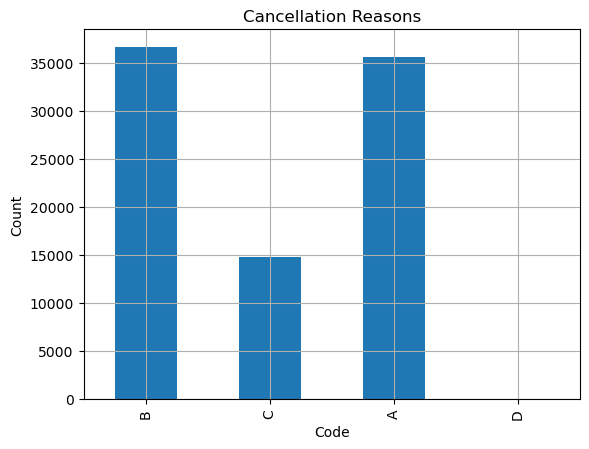

In [13]:
# Convert to Pandas for visualization
cancel_reasons = df_cleaned.filter("cancelled == 1") \
    .groupBy("cancellationCode") \
    .count() \
    .toPandas()

# Plot
import matplotlib.pyplot as plt

cancel_reasons.set_index("cancellationCode").plot(kind="bar", legend=False)
plt.title("Cancellation Reasons")
plt.ylabel("Count")
plt.xlabel("Code")
plt.grid(True)
plt.show()


### Class Distribution for cancelled

In [14]:
df_cleaned.groupBy("cancelled").count().show()


+---------+-------+
|cancelled|  count|
+---------+-------+
|      0.0|6326977|
|      1.0|  87038|
+---------+-------+



In [15]:
cancel_counts = df_cleaned.groupBy("cancelled").count().collect()
cancel_0 = next(r["count"] for r in cancel_counts if r["cancelled"] == 0.0)
cancel_1 = next(r["count"] for r in cancel_counts if r["cancelled"] == 1.0)

imbalance_ratio = cancel_0 / cancel_1 if cancel_1 else float("inf")
print(f"Imbalance ratio (non-cancelled : cancelled) = {imbalance_ratio:.2f} : 1")


Imbalance ratio (non-cancelled : cancelled) = 72.69 : 1


# Task 4

### Feature Selection

In [16]:
categorical_cols = ["uniqueCarrier", "origin", "dest"]
numeric_cols = ["month", "dayOfWeek", "scheduledDepTime"]


### Encoding Categorical Columns

In [17]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder

# Index and encode each categorical feature
indexers = [StringIndexer(inputCol=col, outputCol=col+"_idx", handleInvalid="keep") for col in categorical_cols]
encoders = [OneHotEncoder(inputCol=col+"_idx", outputCol=col+"_vec") for col in categorical_cols]


### Combine with VectorAssembler

In [18]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[col+"_vec" for col in categorical_cols] + numeric_cols,
    outputCol="features"
)


### Full Feature Pipeline

In [19]:
from pyspark.ml import Pipeline

# All transformations in one pipeline
feature_pipeline = Pipeline(stages=indexers + encoders + [assembler])

# Apply the pipeline
df_featurized = feature_pipeline.fit(df_cleaned).transform(df_cleaned)

# Preview final features
df_featurized.select("features", "cancelled").show(5, truncate=False)


+---------------------------------------------------------+---------+
|features                                                 |cancelled|
+---------------------------------------------------------+---------+
|(614,[7,42,329,611,612,613],[1.0,1.0,1.0,1.0,5.0,1100.0])|0.0      |
|(614,[7,33,341,611,612,613],[1.0,1.0,1.0,1.0,5.0,1510.0])|0.0      |
|(614,[7,33,338,611,612,613],[1.0,1.0,1.0,1.0,5.0,1100.0])|0.0      |
|(614,[7,42,329,611,612,613],[1.0,1.0,1.0,1.0,5.0,1240.0])|0.0      |
|(614,[7,45,329,611,612,613],[1.0,1.0,1.0,1.0,5.0,1715.0])|0.0      |
+---------------------------------------------------------+---------+
only showing top 5 rows



# Task 5

### Rename cancelled to label

In [20]:
# Only needed once, after feature engineering
df_model_input = df_featurized.withColumnRenamed("cancelled", "label")


### Sample the Data

In [21]:
# Use 10% of the data to reduce memory load
df_sample = df_model_input.sample(fraction=0.1, seed=42)


### Train/Test Split

In [22]:
train_df, test_df = df_sample.randomSplit([0.7, 0.3], seed=42)


### Train Logistic Regression

In [23]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(labelCol="label", featuresCol="features", maxIter=10)
lr_model = lr.fit(train_df)


### Make Predictions on Test Set

In [24]:
predictions = lr_model.transform(test_df)
predictions.select("label", "prediction", "probability").show(5, truncate=False)


+-----+----------+-----------------------------------------+
|label|prediction|probability                              |
+-----+----------+-----------------------------------------+
|0.0  |0.0       |[0.9910534497076581,0.008946550292341926]|
|0.0  |0.0       |[0.9652843446915564,0.03471565530844356] |
|0.0  |0.0       |[0.9753220945253908,0.02467790547460924] |
|0.0  |0.0       |[0.98109559938652,0.018904400613479977]  |
|0.0  |0.0       |[0.9839784496866102,0.01602155031338981] |
+-----+----------+-----------------------------------------+
only showing top 5 rows



### Evaluate AUC and Accuracy

In [25]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# AUC
evaluator_auc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
auc = evaluator_auc.evaluate(predictions)

# Accuracy
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
acc = evaluator_acc.evaluate(predictions)

print(f"Logistic Regression AUC: {auc:.4f}, Accuracy: {acc:.4f}")


Logistic Regression AUC: 0.6917, Accuracy: 0.9868


### Decision Tree Classifier

In [26]:
from pyspark.ml.classification import DecisionTreeClassifier

dt = DecisionTreeClassifier(labelCol="label", featuresCol="features", maxDepth=5)
dt_model = dt.fit(train_df)

dt_predictions = dt_model.transform(test_df)

# Evaluation
dt_auc = evaluator_auc.evaluate(dt_predictions)
dt_acc = evaluator_acc.evaluate(dt_predictions)
print(f"Decision Tree AUC: {dt_auc:.4f}, Accuracy: {dt_acc:.4f}")


Decision Tree AUC: 0.3797, Accuracy: 0.9867


### Random Forest Classifier

In [27]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=50)
rf_model = rf.fit(train_df)

rf_predictions = rf_model.transform(test_df)

# Evaluation
rf_auc = evaluator_auc.evaluate(rf_predictions)
rf_acc = evaluator_acc.evaluate(rf_predictions)
print(f"Random Forest AUC: {rf_auc:.4f}, Accuracy: {rf_acc:.4f}")


Random Forest AUC: 0.6196, Accuracy: 0.9868


### Gradient Boosted Trees (GBT)

In [28]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(labelCol="label", featuresCol="features", maxIter=20)
gbt_model = gbt.fit(train_df)

gbt_predictions = gbt_model.transform(test_df)

# Evaluation
gbt_auc = evaluator_auc.evaluate(gbt_predictions)
gbt_acc = evaluator_acc.evaluate(gbt_predictions)
print(f"GBT AUC: {gbt_auc:.4f}, Accuracy: {gbt_acc:.4f}")


GBT AUC: 0.6938, Accuracy: 0.9867


### Store Results in a Table

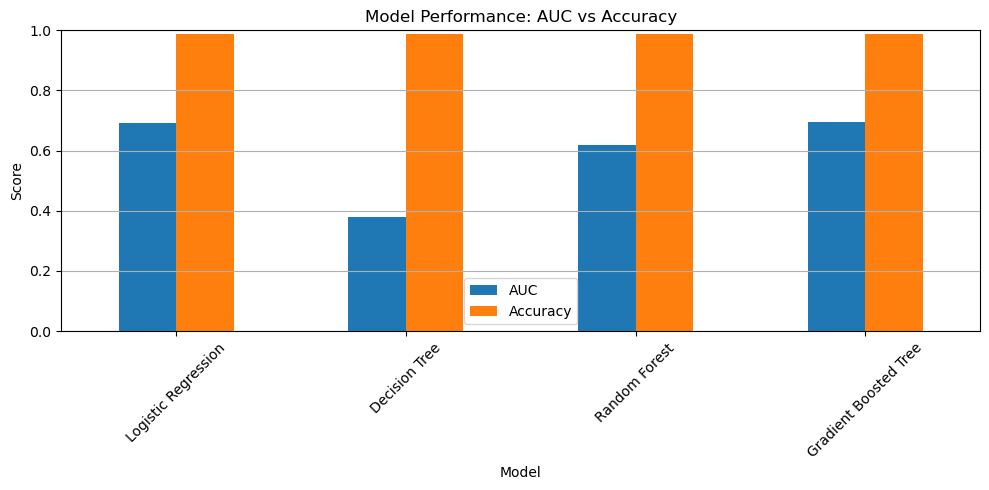

In [29]:
results = [
    {"Model": "Logistic Regression", "AUC": auc, "Accuracy": acc},
    {"Model": "Decision Tree", "AUC": dt_auc, "Accuracy": dt_acc},
    {"Model": "Random Forest", "AUC": rf_auc, "Accuracy": rf_acc},
    {"Model": "Gradient Boosted Tree", "AUC": gbt_auc, "Accuracy": gbt_acc},
]

import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results)
results_df.set_index("Model")[["AUC", "Accuracy"]].plot(kind="bar", figsize=(10, 5))
plt.title("Model Performance: AUC vs Accuracy")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()
